In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

from scipy.integrate import solve_ivp

import sys
sys.path.append('../')
from src.cbf import *
from src.nonlinear_sys import *
from src.mvee import *

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


### Segway Dynamics
$$
\begin{bmatrix}
    \dot{x}_1\\
    \dot{x}_2\\
    \dot{x}_3\\
    \dot{x}_4
\end{bmatrix}
=
\begin{bmatrix}
    x_3\\
    x_4\\
    f_v(x_2, x_4)\\
    f_w(x_2, x_4)
\end{bmatrix}
+
\begin{bmatrix}
    0 \\
    0 \\
    g_v(x_2)\\
    g_w(x_2)
\end{bmatrix}
u
$$

Where
$$
\begin{aligned}
f_v(x_2, x_4) &= \frac{a x_4^2 \sin(x_2) - g \sin(x_2) \cos(x_2)}{b - \cos^2(x_2)}\\
f_w(x_2, x_4) &= \frac{c \sin(x_2) - x_4^2 \sin(x_2) \cos(x_2)}{b - \cos^2(x_2)}\\
g_v(x_2) &= \frac{A+B \cos(x_2)}{b - \cos^2(x_2)}\\
g_w(x_2) &= -\frac{C + D \cos(x_2)}{b - \cos^2(x_2)}
\end{aligned}
$$


refer to:

[`T. G. Molnar, A. K. Kiss, A. D. Ames and G. Orosz, "Safety-Critical Control With Input Delay in Dynamic Environment," in IEEE Transactions on Control Systems Technology, vol. 31, no. 4, pp. 1507-1520, July 2023, doi: 10.1109/TCST.2022.3227451.`](https://ieeexplore.ieee.org/document/9987680)

In [2]:
# Model Parameters
grav = 9.81
R = 0.195
m0 = 52.710
J0 = 5.108
a = 0.6788
b = 4.7274
c = 68.5205
A = 1.1605
B = 0.3344
C = 2.3355
D = 1.7147
q0 = 0.138
l_height = 0.75

alpha = 1       # class K function

d_real = 0.1    # noise parameter

In [3]:
# Follows notation from paper
def fv(q, w):
    return (a*w*w*np.sin(q)-grav*np.sin(q)*np.cos(q))/(b-np.cos(q)*np.cos(q))

def fw(q, w):
    return (c*np.sin(q)-w*w*np.sin(q)*np.cos(q))/(b-np.cos(q)*np.cos(q))

def gv(q):
    return (A+B*np.cos(q))/(b-np.cos(q)*np.cos(q))

def gw(q):
    return -(C+D*np.cos(q))/(b-np.cos(q)*np.cos(q))

In [4]:
def f(x):
    return np.array([x[2], x[3], fv(x[1], x[3]), fw(x[1], x[3])])

def g(x):
    return np.array([0, 0, gv(x[1]), gw(x[1])])

def h(x):
    return 0.5 - 0.5*(3*x[1]*x[1]+2*x[1]*x[3]+x[3]*x[3])

def dh(x):
    return np.array([0, -3*x[1]-x[3], 0, -x[1]-x[3]])

In [5]:
segway = ControlAffine(f, g, n=4)

# Nominal controller
def ctrl(x,t):
    K = np.array([10, 117.5, 17.64, 29.46])
    return K@x

# state estimation function (add adverserial noise)
def est(x, t, d=d_real):
    theta = np.arctan2(x[3], x[1])
    return x - d*np.array([np.zeros_like(theta), np.cos(theta), np.zeros_like(theta), np.sin(theta)])

# Nominal controller with state estimate
def est_ctrl(x, t, d=d_real):
    return ctrl(est(x,t,d), t)

In [6]:
k1 = 1
k2 = 1      # Robust CBF constants

cbf = CBF(alpha, h, dh, segway)
rob_cbf = Rob_CBF(alpha, h, dh, segway, k1, k2)
iss_cbf = Rob_CBF(alpha, h, dh, segway, 0, k2)

In [7]:
def reform_cbf(hat_x,cbf:CBF,kd,eps=0.1):
    a_func = lambda x: cbf.Lgh(x)
    b_func = lambda x: cbf.Lfh(x) + cbf.a*cbf.h(x)

    # sample in the state uncertainty set and find mvee in the (a,b) space
    x_sample = sample_uniform_ball(N=1000, d=4, R=eps) + hat_x
    a_x = np.array([a_func(x) for x in x_sample])  # (N,)
    b_x = np.array([b_func(x) for x in x_sample])  # (N,)
    z_sample = np.column_stack([a_x,b_x])


    # (z-c)^T P (z-c) <= 1 => z^T*P*z - c^T*P^T*z -c^T*P*z + c^T*P*c - 1 <=0  
    c, P = safe_cov_ellipsoid(z_sample)
    q, r = -c.T @ (P + P.T), c.T@P@c - 1 
    scale= max(np.linalg.norm(q),abs(r))
    P, q, r = P/scale, q/scale, r/scale

    # formulate the SDP
    def solve_sdp(m: int,
                kd_xhat: np.ndarray,        # shape (m,)
                P: np.ndarray,              # shape (m+1, m+1), PSD
                q: np.ndarray,              # shape (m+1,)
                r: float,
                u_min: np.ndarray = None,   # shape (m,)
                u_max: np.ndarray = None,   # shape (m,)
                solver="CVXOPT"):
        """
        Solves:
        minimize    s
        s.t.        [ s      (u-kd)^T ]  >= 0
                    [ u-kd      I     ]

                    [ 4t    ([u^T 1] + λ q^T) ] >= 0
                    [ ([u;1] + λ q)     λ P   ]

                    r λ - t >= 0,  λ >= 0,  u ∈ U

        Returns u*, lambda*, s*, t*.
        """

        kd_xhat = np.asarray(kd_xhat).reshape(-1)
        q = np.asarray(q).reshape(-1)
        assert kd_xhat.shape == (m,)
        assert q.shape == (m+1,)
        assert P.shape == (m+1, m+1)

        # Decision variables
        u = cp.Variable(m)
        lam = cp.Variable(nonneg=True)
        s = cp.Variable()
        t = cp.Variable()

        # --- Build LMI #1: [[s, (u-kd)^T],[u-kd, I]] >= 0 ---
        delta = u - kd_xhat  # (m,)
        s11 = cp.reshape(s, (1, 1))
        s12 = cp.reshape(delta, (m, 1)).T          # (1,m)
        s21 = cp.reshape(delta, (m, 1))            # (m,1)
        s22 = np.eye(m)

        LMI1 = cp.bmat([[s11, s12],
                        [s21, s22]])

        # --- Build LMI #2: [[4t, [u^T 1] + lam q^T], [[u;1]+lam q, lam P]] >= 0 ---
        top_left = cp.reshape(4 * t, (1, 1))

        # [u^T 1] as a row (1, m+1)
        u_row = cp.reshape(cp.hstack([u, [1.0]]), (1, m+1))
        q_row = cp.reshape(q, (1, m+1))
        top_right = u_row + lam * q_row            # (1, m+1)

        # [u; 1] as a col (m+1, 1)
        u_col = cp.reshape(cp.vstack([u, [1.0]]), (m+1, 1))
        q_col = cp.reshape(q, (m+1, 1))
        bot_left = u_col + lam * q_col             # (m+1, 1)

        P_c = cp.psd_wrap(0.5*(P + P.T))
        bot_right = lam * P_c
        # bot_right = lam * P                        # (m+1, m+1)

        LMI2 = cp.bmat([[top_left,  top_right],
                        [bot_left,  bot_right]])

        constraints = [
            LMI1 >> 0,
            LMI2 >> 0,
            r * lam - t >= 0,    # i.e., t <= r*lam
        ]
        constraints += [lam >= 1e-6]
        constraints += [t >= 0, s >= 0]


        # Example convex set U: box constraints u_min <= u <= u_max
        if u_min is not None:
            constraints.append(u >= u_min)
        if u_max is not None:
            constraints.append(u <= u_max)

        prob = cp.Problem(cp.Minimize(s), constraints)

        # NOTE: ECOS does NOT solve SDPs. Use SCS / MOSEK / CVXOPT, etc.
        if solver.upper() == "CVXOPT":
            prob.solve(solver=cp.CVXOPT, verbose=False, eps=1e-6, max_iters=20000)
        else:
            prob.solve(solver=solver, verbose=False)

        return u.value, lam.value, s.value, t.value, prob.status

    u_star, lam_star,s_star,t_star,status = solve_sdp(m=1,kd_xhat=kd,P=P,q=q,r=r)
    # u_star, lam_star, s_star, t_star, status = solver_obj.solve(
    #     kd_val=kd,
    #     P_val=P,
    #     q_val=q,
    #     r_val=r
    # )
    if status not in ("optimal"):
        print(f'Warning: SDP solver gets status: {status}')
        if u_star is None:
            return kd

    return u_star

### Simulation

In [8]:
x0 = np.array([-4, -0.5, 0, 1])

tend = 10
num_steps = 5000

time = np.linspace(0, tend, num_steps+1)

traj = solve_ivp(lambda t,y : segway.RHS(y, ctrl(y, t)), (0, tend), x0, t_eval=time).y
cbf_traj = solve_ivp(lambda t, y : segway.RHS(y, cbf.filter(y, ctrl(y,t))), (0, tend), x0, t_eval=time).y

# State Estimation Error Included - (Using true state for nominal controller)
cbf_traj_est = solve_ivp(lambda t, y : segway.RHS(y, cbf.filter(est(y,t), ctrl(y, t))), (0, tend), x0, t_eval=time).y
rob_cbf_traj = solve_ivp(lambda t, y : segway.RHS(y, rob_cbf.filter(est(y,t), ctrl(y, t))), (0, tend), x0, t_eval=time).y

reform_cbf_traj_est = solve_ivp(lambda t, y : segway.RHS(y, reform_cbf(est(y,t),cbf,ctrl(y, t),eps=d_real)), (0, tend), x0, t_eval=time).y


c:\Users\rahal\miniconda3\Lib\site-packages\cvxpy\atoms\affine\reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)


### Plotting

In [9]:
def plot_region(border=True):
    x0 = np.linspace(-2, 2, 400)
    x1 = np.linspace(-2, 2, 400)
    X0, X1 = np.meshgrid(x0, x1)

    Z = h([0, X0, 0 ,X1])

    fig, ax = plt.subplots(figsize=(3, 6))

    plt.contourf(X0, X1, Z, levels=[0, np.inf], colors='palegreen', alpha=0.7) # Shade where Z > 0
    if border:
        plt.contour(X0, X1, Z, levels=[0], colors='black', linewidths=2)

    plt.xlabel('$\\phi$')
    plt.ylabel('$\\omega$')

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim([-0.75, 0.75])
    plt.ylim([-1.5, 2])
    ax.set_xticks([-0.5, 0, 0.5])
    ax.set_yticks([-1, 0, 1])
    # ax.tick_params(axis="y",direction="in", pad=-15)
    # ax.tick_params(axis="x",direction="in", pad=-15)
    ax.xaxis.set_label_coords(0.5, -0.05)
    ax.yaxis.set_label_coords(-0.1, 0.38)

def plot_traj(traj, color=None, label=None, num_arrows=3, arrow_length=0.01, arrow_indices=None):
    traj = traj[[1,3]]
    line, =plt.plot(traj[0], traj[1], linewidth=2, color=color, label=label)
    # print(arrow_indices)
    if arrow_indices is None:
        arrow_indices = range(0, len(traj[0]), len(traj[0])//(num_arrows+1))
    for i in arrow_indices:
        if 0 < i < len(traj[0]) - 1: # Ensure the indices are valid.
            dx = traj[0][i + 1] - traj[0][i]
            dy = traj[1][i + 1] - traj[1][i]

            # Normalize the arrow vector
            magnitude = np.sqrt(dx**2 + dy**2)
            if magnitude != 0: #Avoid division by zero.
                dx = dx / magnitude * arrow_length
                dy = dy / magnitude * arrow_length

                plt.arrow(traj[0][i], traj[1][i], dx, dy,
                            head_width=0.08, head_length=0.08, fc=line.get_color(), ec=line.get_color())

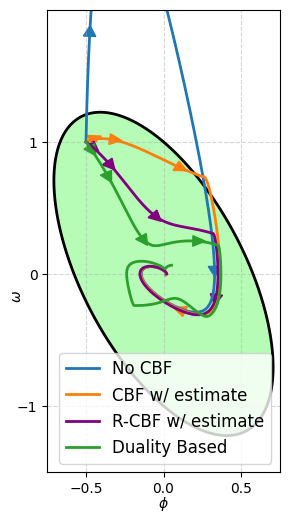

In [10]:
arrow_indices = [8, 70, 300, 1000]

plot_region()
plot_traj(traj, label="No CBF", arrow_indices=arrow_indices[:-1])
# plot_traj(cbf_traj, label="CBF w/ true state", arrow_indices=arrow_indices)
plot_traj(cbf_traj_est, label="CBF w/ estimate", arrow_indices=arrow_indices)
plot_traj(rob_cbf_traj, label="R-CBF w/ estimate", arrow_indices=arrow_indices, color="purple")
plot_traj(reform_cbf_traj_est, label="Duality Based", arrow_indices=arrow_indices)


plt.legend(loc="lower right", fontsize=12)
plt.savefig("figs/segway_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()

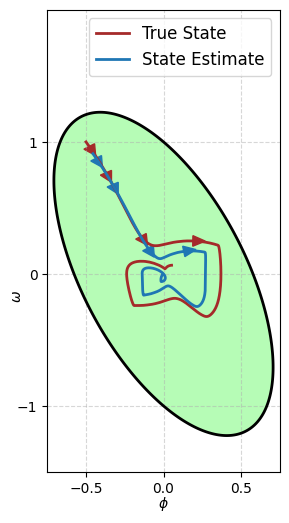

In [11]:
plot_region()

# plot_traj(rob_cbf_traj, color="green", label="True State R-CBF", arrow_indices=arrow_indices)
# plot_traj(est(rob_cbf_traj, 0), label="Estimated State R-CBF", arrow_indices=arrow_indices)

plot_traj(reform_cbf_traj_est, color="brown", label="True State", arrow_indices=arrow_indices)
plot_traj(est(reform_cbf_traj_est, 0), label="State Estimate", arrow_indices=arrow_indices)

plt.legend(loc="upper right", fontsize=12)
plt.savefig("figs/segway_true_est.pdf", format="pdf", bbox_inches="tight")
plt.show()

d = 0.05 

d = 0.1 

d = 0.13 



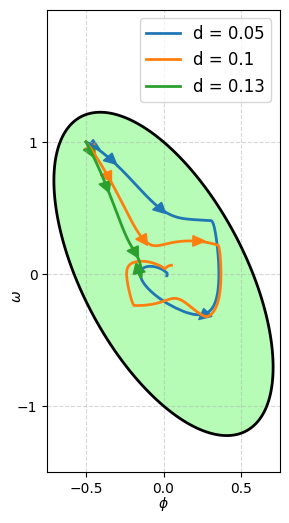

In [12]:
d_reals = [0.05, 0.1, 0.13]

r_cbf_trajs = []

for d in d_reals:
    print(f'd = {d} \n')
    r_cbf_trajs.append(solve_ivp(lambda t, y : segway.RHS(y, reform_cbf(est(y,t),cbf,ctrl(y, t),eps=d)), (0, tend), x0, t_eval=time).y)

plot_region()
for i, rcbf_traj in enumerate(r_cbf_trajs):
    plot_traj(rcbf_traj, label="d = "+str(d_reals[i]), arrow_indices=arrow_indices)

plt.legend(fontsize=12)
plt.savefig("figs/segway_multi_d_osc.pdf", format="pdf", bbox_inches="tight")
plt.show()

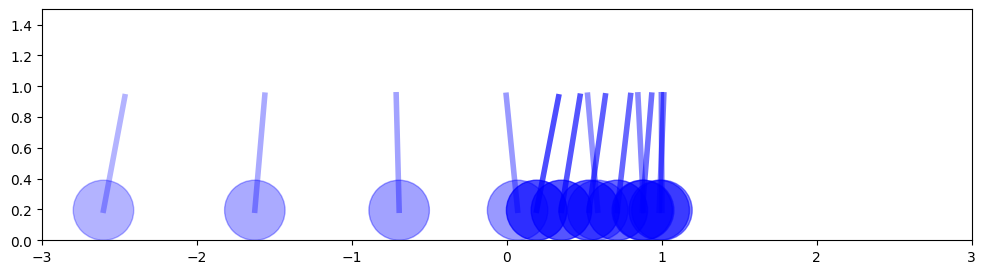

In [13]:
N_DRAWS = 20

def draw_segway(x, alpha=1):
    circle = plt.Circle((x[0], R), R, fill=True, color='blue', alpha=alpha)
    plt.gca().add_patch(circle)
    plt.plot([x[0], x[0] + l_height * np.sin(x[1]+q0)], [R, R + l_height * np.cos(x[1]+q0)], color='blue', linewidth=4, alpha=alpha)

    plt.xlim([-3,3])
    plt.ylim([0,1.5])

plt.figure(figsize=(12,3))
for i in range(0, len(time), len(time)//(N_DRAWS+1)):
    draw_segway(reform_cbf_traj_est[:, i], alpha=(0.7*i/len(time)))
plt.show()